In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
from pynitride import Mesh, NodFunction, MaterialBlock, UniformLayer
from pynitride.physics.material import AlGaN
from pynitride import to_unit, nm, eV, cm, parse
from pynitride.core.maths import dephase
from pynitride import log
from pynitride import Simulation
import numpy as np

In [3]:
from pynitride.core.paramdb import to_unit

In [4]:
from pynitride.examples.AlGaN_GaN_HEMT.hemt_example import define_mesh

In [ ]:
for barr_t in np.r_[5,10,15]*nm:
    print(f"Starting barr_t={barr_t}")
    sim=Simulation(f"HEMT_{barr_t}",define_mesh,Simulation.flow_semiclassicalramp_schrodinger,
                   mesh_opts={'barr_t':barr_t})
    sim.load(force=False)

    m,schro=sim.dmeshes['main'],sim.dmeshes['schro']
    #m.plot_mesh()
    #plt.tight_layout()


    # Check normalization
    
    wf0=schro.schro_e_psi[0,0,:]
    wf1=schro.schro_e_psi[0,1,:]
    from pynitride.core.mesh import inner_product
    assert np.isclose(inner_product(wf0,wf0),1,atol=1e-8)
    assert np.isclose(inner_product(wf0,wf1),0,atol=1e-8)
    print("Total electrons: {:.2g} x10^13/cm^2 for barr_t={:g}".format(to_unit(float(m.n.integrate(definite=True)),"1e13/cm^2"),barr_t))
    
    
    break

Starting barr_t=5
2023-07-16 22:23:55.839409     Mesh points: 627
2023-07-16 22:23:55.844135     Hoping to load previous run from HEMT_5*
> c:\users\sbader\nondrive\pynitride\pynitride\core\sim.py(229)loader_standard()
    227         with sublog("Hoping to load previous run from " + os.path.join(sim._outdir,sim.name+"*")):
    228             import pdb; pdb.set_trace()
--> 229             try:
    230                 m=sim.dmeshes.get('main',False)
    231                 if m:

ipdb> n
> c:\users\sbader\nondrive\pynitride\pynitride\core\sim.py(230)loader_standard()
    228             import pdb; pdb.set_trace()
    229             try:
--> 230                 m=sim.dmeshes.get('main',False)
    231                 if m:
    232                     m.read(os.path.join(sim._outdir, sim.name+"_direct.npz"))

ipdb> n
> c:\users\sbader\nondrive\pynitride\pynitride\core\sim.py(231)loader_standard()
    229             try:
    230                 m=sim.dmeshes.get('main',False)
--> 231  

ipdb> m._submeshes
[<Mesh(627) "epi">, <Mesh(557) "schro">, <Mesh(71) "semi">]
ipdb> m._submeshes[1]._non_mesh_items
{}
ipdb> m._submeshes[1]._functions
{'EF': Function([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 

ipdb> m._submeshes[1]._functions.keys()
dict_keys(['EF', 'T', 'exx', 'eyy', 'ezz', 'exy', 'exz', 'eyz', 'rho', 'rhoderiv', 'fixedcharge', 'Ndp', 'Nam', 'Ndpderiv', 'Namderiv', 'DP', 'phi', 'eps', 'DE', 'Ec-E0', 'Ec', 'Eg', 'Ev', 'E', 'n', 'nderiv', 'p', 'pderiv', 'Nc', 'Nv'])


In [11]:
schro._non_mesh_items

{}

In [8]:
schro._functions.keys()

dict_keys(['EF', 'T', 'exx', 'eyy', 'ezz', 'exy', 'exz', 'eyz', 'rho', 'rhoderiv', 'fixedcharge', 'Ndp', 'Nam', 'Ndpderiv', 'Namderiv', 'DP', 'phi', 'eps', 'DE', 'Ec-E0', 'Ec', 'Eg', 'Ev', 'E', 'n', 'nderiv', 'p', 'pderiv', 'Nc', 'Nv'])

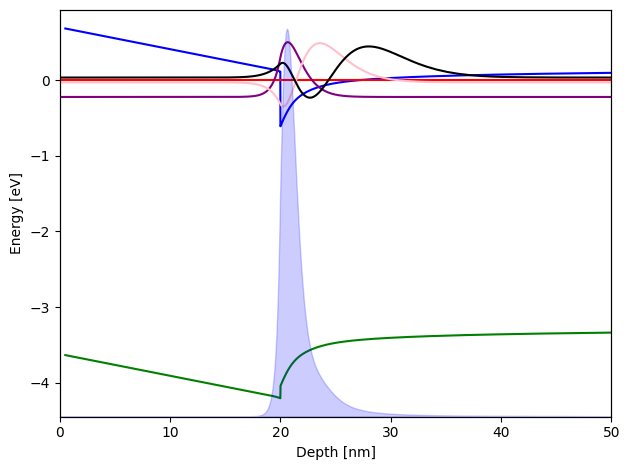

In [6]:

if 1:
    plt.figure()
    plt.plot(m.zm,m.Ec,'b')
    plt.plot(m.zm,m.Ev,'g')
    plt.plot(m.zn, m.EF, 'r')
    plt.plot(schro.zn, dephase(schro.schro_e_psi[0, 0, :]) + schro.schro_e_en[0, 0], 'purple')
    plt.plot(schro.zn, dephase(schro.schro_e_psi[0, 1, :]) + schro.schro_e_en[0, 1], 'pink')
    plt.plot(schro.zn, dephase(schro.schro_e_psi[0, 2, :]) + schro.schro_e_en[0, 2], 'black')
    plt.ylabel("Energy [eV]")
    plt.xlabel("Depth [nm]")
    plt.twinx()
    plt.fill_between(m.zn, m.n, color='b', alpha=.2)
    plt.xlim(0,50*nm)
    plt.ylim(0)
    plt.yticks([])
    plt.tight_layout()
    plt.show()


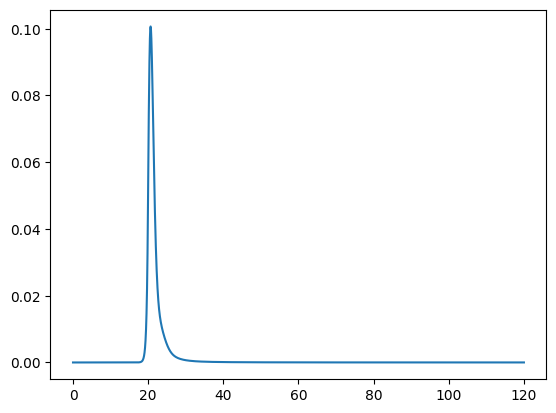

In [7]:
#sim.dmeshes['main'].Psp.plot()
sim.dmeshes['main'].n.plot()

In [23]:
#to_unit(
sim.dmeshes['main'].n.integrate(definite=True)#,
#"1/cm^2")

Function([-1.73490810e-16,  1.83646821e-14,  5.57946279e-14,
           1.69512355e-13,  5.15003680e-13,  1.56465778e-12,
           4.63024754e-12,  1.13021360e-11,  2.31510588e-11,
           4.22358809e-11,  7.07686526e-11,  1.11135725e-10,
           1.65878503e-10,  2.37679601e-10,  3.29352999e-10,
           4.43837293e-10,  5.84191494e-10,  7.53592968e-10,
           9.55337297e-10,  1.19283987e-09,  1.46963910e-09,
           1.78940126e-09,  2.15592684e-09,  2.57315851e-09,
           3.04519075e-09,  3.57628120e-09,  4.17086375e-09,
           4.83356372e-09,  5.56921501e-09,  6.38287960e-09,
           7.27986950e-09,  8.26577137e-09,  9.34647406e-09,
           1.05281993e-08,  1.18175361e-08,  1.32214782e-08,
           1.47474668e-08,  1.64034365e-08,  1.81978668e-08,
           2.01398389e-08,  2.22390975e-08,  2.45061196e-08,
           2.69521893e-08,  2.95894799e-08,  3.24311441e-08,
           3.54914120e-08,  3.87856984e-08,  4.23307197e-08,
           4.61446211e-0

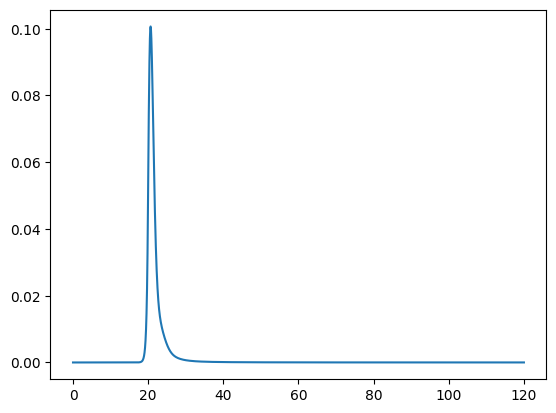

In [45]:
sim.dmeshes['main'].n.plot()

In [30]:
sim.dmeshes['main'].zm

array([  0.5       ,   1.5       ,   2.5       ,   3.5       ,
         4.5       ,   5.5       ,   6.41907014,   7.1727226 ,
         7.78487974,   8.29915682,   8.74191342,   9.13023666,
         9.47580589,   9.78694249,  10.06977668,  10.32895012,
        10.56805898,  10.78994427,  10.99688824,  11.19075119,
        11.37306887,  11.54512349,  11.70799632,  11.86260745,
        12.00974611,  12.1500943 ,  12.28424528,  12.41271825,
        12.53597015,  12.65440519,  12.76838263,  12.87822319,
        12.98421435,  13.08661476,  13.18565797,  13.28155559,
        13.3744999 ,  13.46466614,  13.55221449,  13.63729172,
        13.72003261,  13.8005613 ,  13.87899228,  13.95543144,
        14.02997688,  14.10271963,  14.17374436,  14.24312991,
        14.31094984,  14.3772729 ,  14.44216339,  14.50568159,
        14.56788408,  14.62882398,  14.68855131,  14.74711314,
        14.80455391,  14.86091553,  14.91623763,  14.9705577 ,
        15.02391125,  15.07633191,  15.12785163,  15.17

In [20]:
np.ravel()[0]

22581420663324.824

In [10]:
sim.dmeshes['main']._functions.keys()

dict_keys(['EF', 'T', 'exx', 'eyy', 'ezz', 'exy', 'exz', 'eyz', 'rho', 'rhoderiv', 'fixedcharge', 'Ndp', 'Nam', 'Ndpderiv', 'Namderiv', 'DP', 'phi', 'eps', 'DE', 'Ec-E0', 'Ec', 'Eg', 'Ev', 'E', 'n', 'nderiv', 'p', 'pderiv', 'Nc', 'Nv', 'Psp'])